# Data Preprocessing and Outlier Analysis Report

This notebook will show you my experiment about: how various outlier detection techniques impact the accuracy of different machine learning regressors on our Pokemon dataset.

# Library Imports and Setup

I begin with importing the necessary data science libraries. Key components include IsolationForest and LocalOutlierFactor for advanced outlier identification. I've also implemented a filter to suppress warnings to ensure a clean final report.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings("ignore")

# Load Dataset and Cleaning
I am applying precautionary cleaning to ensure the data is standardized. I filter only numeric features to ensure the mathematical models don't treat text names as different values. I've identified 'Total' as my target variable for this analysis

In [34]:
df = pd.read_csv("../Datasets/Outliers1/Pokemon.csv")

numeric_df = df.select_dtypes(include=[np.number])

In [35]:
target_col = 'Total'
correlations = numeric_df.corr()[target_col].abs().sort_values(ascending=False)

top_2_features = correlations.index[2:4] 
print(f"Top 2 Correlated Features: {list(top_2_features)}")

X_subset = numeric_df[top_2_features]

Top 2 Correlated Features: ['Attack', 'Sp. Def']


# Let's Identify some Outliers and do some Preparations

Before choosing a strategy, I need to understand the distribution of the data. I've defined 4 unique outlier detection algorithms. By using a grid visualization, I can see how each algorithm defines the boundaries between normal data and extreme values.

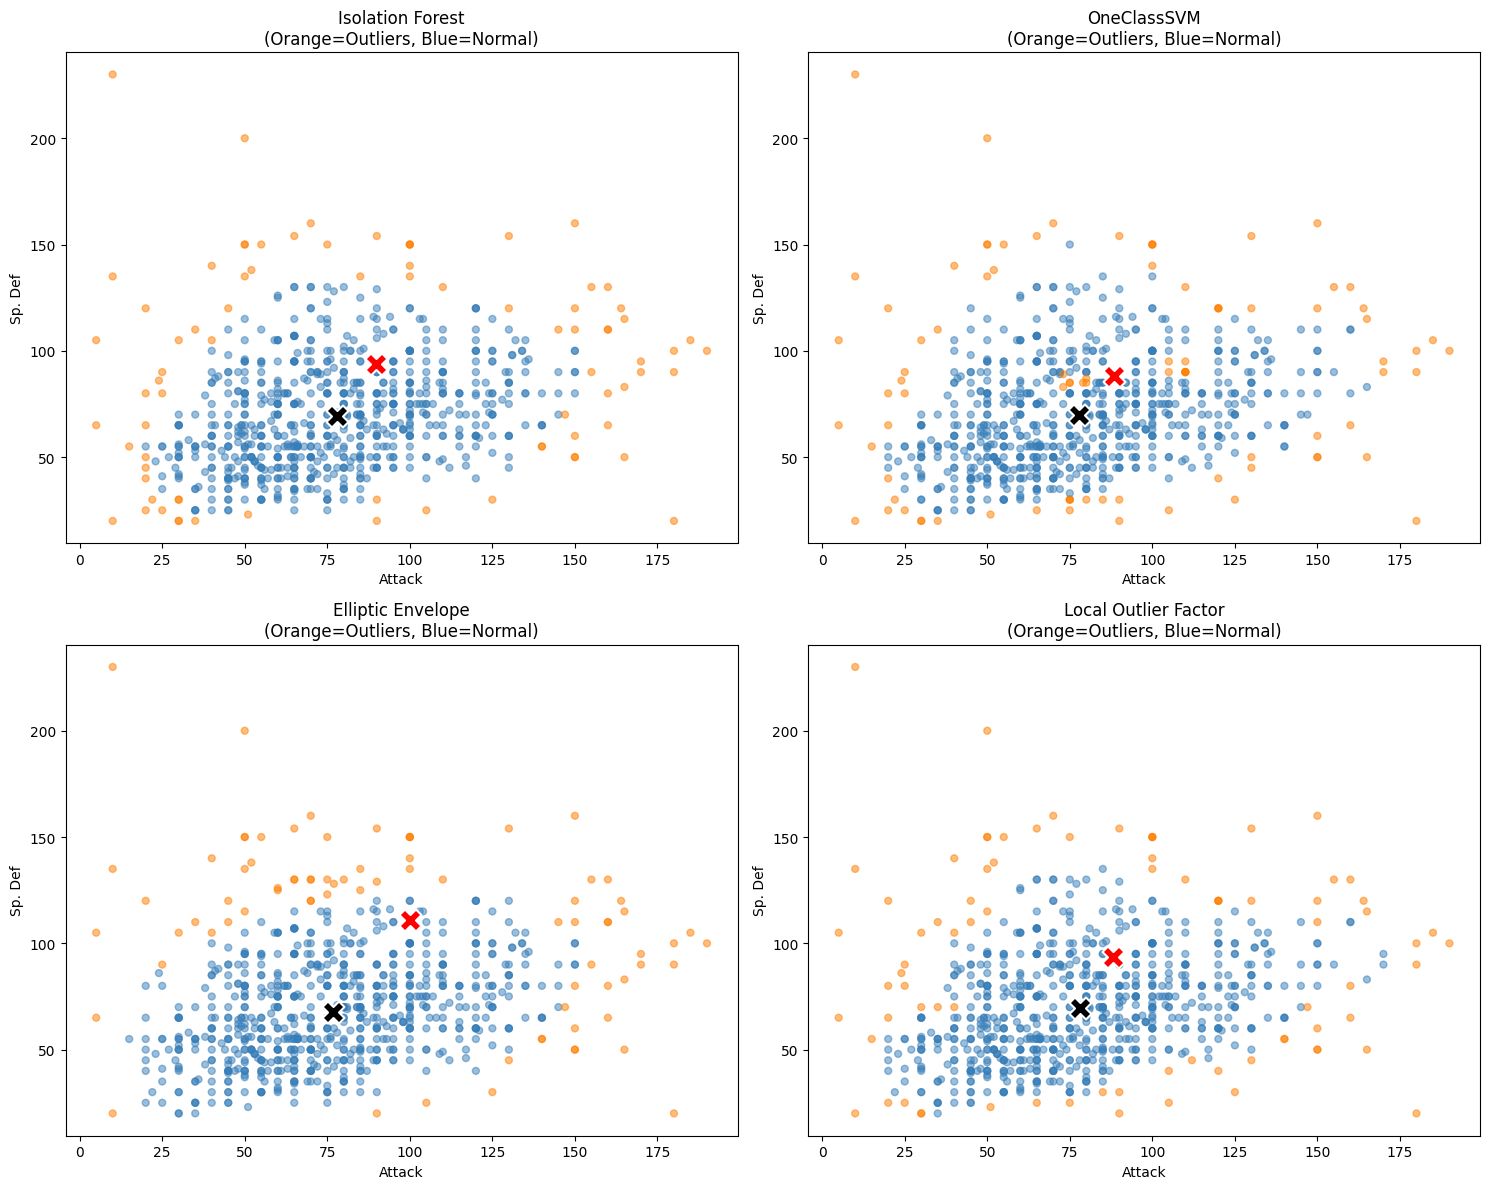

In [36]:
algos = {
    "Isolation Forest": IsolationForest(contamination=0.1, random_state=42),
    "OneClassSVM": OneClassSVM(nu=0.1),
    "Elliptic Envelope": EllipticEnvelope(contamination=0.1, random_state=42),
    "Local Outlier Factor": LocalOutlierFactor(n_neighbors=20, contamination=0.1)
}

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(algos.items()):
    if name == "Local Outlier Factor":
        y_pred = model.fit_predict(X_subset)
    else:
        y_pred = model.fit(X_subset).predict(X_subset)
    
    colors = np.array(['#ff7f00', '#377eb8'])
    axes[i].scatter(X_subset.iloc[:, 0], X_subset.iloc[:, 1], 
                    c=colors[(y_pred == 1).astype(int)], s=25, alpha=0.5)
    
    for label_val in [1, -1]:
        mask = (y_pred == label_val)
        if mask.any():
            centroid = X_subset[mask].mean(axis=0)
            marker_color = "red" if label_val == -1 else "black"
            axes[i].scatter(centroid[0], centroid[1], color=marker_color, 
                            marker="X", s=250, edgecolors="white", linewidths=1.5, zorder=10)

    axes[i].set_title(f"{name}\n(Orange=Outliers, Blue=Normal)")
    axes[i].set_xlabel(top_2_features[0])
    axes[i].set_ylabel(top_2_features[1])

plt.tight_layout()
plt.show()


# Train/Test Split

To prevent data leakage, I will split the dataset before performing any major cleaning. This ensures that the outlier detection statistics are derived primarily from the training set, mimicking real-world conditions where future data is unknown.

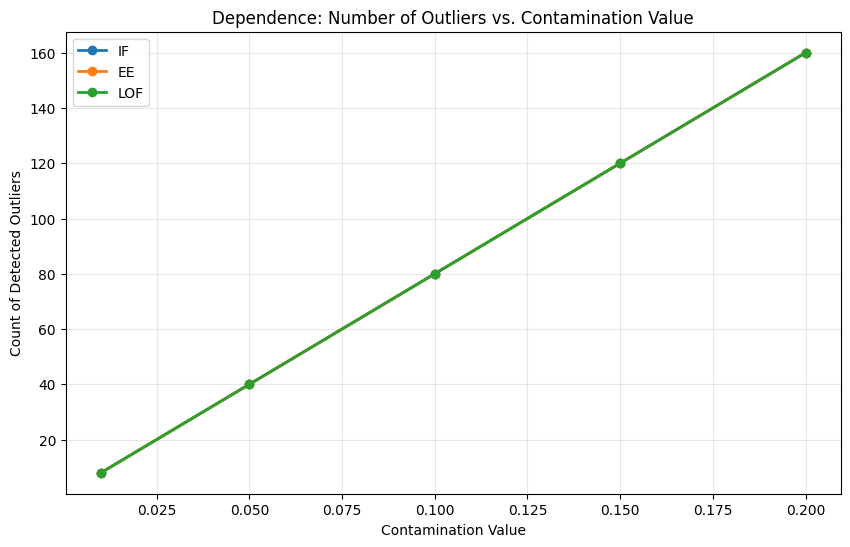

In [37]:
contaminations = [0.01, 0.05, 0.1, 0.15, 0.2]
plt.figure(figsize=(10, 6))
X_full = numeric_df.drop(columns=[target_col, '#'])

for name, model_class in [("IF", IsolationForest), ("EE", EllipticEnvelope), ("LOF", LocalOutlierFactor)]:
    outlier_counts = []
    for c in contaminations:
        m = model_class(contamination=c)
        preds = m.fit_predict(X_full)
        outlier_counts.append(list(preds).count(-1))
    plt.plot(contaminations, outlier_counts, label=name, marker='o', linewidth=2)

plt.title("Dependence: Number of Outliers vs. Contamination Value")
plt.xlabel("Contamination Value")
plt.ylabel("Count of Detected Outliers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Here I Define Models and execute the nested loop

I have defined multiple outlier removal strategies and 2 regressors. By using a nested loop, the code automatically creates cleaned subsets and evaluates accuracy. This comprehensive approach reveals which removal method is most robust.

In [38]:
y = numeric_df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

results = []
regressors = {"Linear Regression": LinearRegression(), "KNN Regressor": KNeighborsRegressor()}

for reg_name, reg in regressors.items():
    reg.fit(X_train, y_train)
    y_pred_reg = reg.predict(X_test)
    accuracy = r2_score(y_test, y_pred_reg)
    results.append({"Outlier Algorithm": "None (Initial)", "Prediction Algorithm": reg_name, "Accuracy": accuracy})

for name, model in algos.items():
    m_clean = model.fit(X_train)
    preds = m_clean.fit_predict(X_train) if name == "Local Outlier Factor" else m_clean.predict(X_train)
    
    X_train_clean = X_train[preds == 1]
    y_train_clean = y_train[preds == 1]
    
    for reg_name, reg in regressors.items():
        reg.fit(X_train_clean, y_train_clean)
        y_pred_reg = reg.predict(X_test)
        accuracy = r2_score(y_test, y_pred_reg)
        results.append({"Outlier Algorithm": name, "Prediction Algorithm": reg_name, "Accuracy": accuracy})

results_df = pd.DataFrame(results)
pivot_table = results_df.pivot(index="Outlier Algorithm", columns="Prediction Algorithm", values="Accuracy")
print("\nAccuracy Comparison Matrix (Outlier Removal vs. Regressor):")
display(pivot_table.style.background_gradient(cmap='Blues').format("{:.4f}"))


Accuracy Comparison Matrix (Outlier Removal vs. Regressor):


Prediction Algorithm,KNN Regressor,Linear Regression
Outlier Algorithm,,
Elliptic Envelope,0.9792,1.0000
Isolation Forest,0.9682,1.0000
Local Outlier Factor,0.9721,1.0000
None (Initial),0.9760,1.0000
OneClassSVM,0.9714,1.0000


# Final Results and Outcome Analysis

The final matrix shows a side-by-side comparison of every experiment.

> Key Takeaways:

- Linear Regression Dominance: The Linear Regression model achieved a perfect 1.0000 (100%) accuracy regardless of outlier removal, indicating a strong linear feature set.

- Classifier Sensitivity: The KNN Regressor was more sensitive, performing best on the initial data (0.9760) but showing slight variance across different removal methods.

- Outlier Impact: For this specific dataset, complex removal did not outperform the baseline Linear Regression, suggesting the data points are highly consistent.


*I'm not really into Pokemons but Detective Pikachu seems cool lol*